# 01 · MLPerf EDA & Reliability Validation

**Purpose:** Validate the corpus before any feature engineering or model training begins.

| § | Mode | Title | Status |
|---|------|-------|--------|
| 1 | Gate | Reliability audit | complete |
| 2 | Gate | `TOKENS_PER_SAMPLE` verification | complete |
| 3 | Gate | Row-count cross-check | complete |
| 4 | Learn | Coverage & distribution | complete |
| 5 | Learn | Target variable analysis | complete |
| 6 | Learn | Feature candidate sketches | complete |

**Rule:** §1 and §2 must both pass before model training begins.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as sp_stats

# append, not insert(0) — inserting at 0 puts the project root before stdlib,
# which means a file named re.py / json.py / pathlib.py in the repo root would
# silently shadow the real module.
sys.path.append(str(Path("..").resolve()))

from src.data.mlperf_parser import LLM_BENCHMARKS, TOKENS_PER_SAMPLE

sns.set_theme(style="whitegrid", palette="muted")

In [2]:
DATA_PATH = Path("..") / "data" / "processed" / "mlperf_raw.parquet"
df = pd.read_parquet(DATA_PATH)
print(f"{len(df):,} rows × {df.shape[1]} columns  |  {DATA_PATH.resolve()}")

1,223 rows × 27 columns  |  /Users/victoriaalabi/Projects/gpu-perf-prophet/data/processed/mlperf_raw.parquet


In [3]:
df.shape

(1223, 27)

In [4]:
df.columns

Index(['round', 'division', 'submitter', 'system_name', 'gpu_name', 'num_gpus',
       'vram_gb', 'framework', 'system_type', 'hw_status', 'benchmark',
       'benchmark_base', 'benchmark_accuracy_tier', 'scenario', 'precision',
       'tokens_per_sample', 'throughput_tokens_per_sec',
       'throughput_tok_per_sec_per_gpu', 'result_valid',
       'throughput_samples_per_sec', 'latency_mean_ms', 'latency_p99_ms',
       'ttft_mean_ms', 'ttft_p99_ms', 'tpot_mean_ms', 'tpot_p99_ms',
       'log_path'],
      dtype='object')

In [5]:
df.head()

,round,division,submitter,system_name,gpu_name,num_gpus,vram_gb,framework,system_type,hw_status,...,throughput_tok_per_sec_per_gpu,result_valid,throughput_samples_per_sec,latency_mean_ms,latency_p99_ms,ttft_mean_ms,ttft_p99_ms,tpot_mean_ms,tpot_p99_ms,log_path
0,v4.1,closed,AMD,1xMI300X_2xEPYC-9374F,AMD Instinct MI300X-NPS1-SPX-192GB-750W,1,192.0,"vLLM 0.4.3+rocm614, PyTorch 2.3.0, ROCm 6.1.2",datacenter,available,...,3070.6830,True,10.4445,2.352903e+06,2.352997e+06,NaN,NaN,NaN,None,closed/AMD/results/1xMI300X_2xEPYC-9374F/llama...
1,v4.1,closed,AMD,1xMI300X_2xEPYC-9374F,AMD Instinct MI300X-NPS1-SPX-192GB-750W,1,192.0,"vLLM 0.4.3+rocm614, PyTorch 2.3.0, ROCm 6.1.2",datacenter,available,...,2534.2800,True,8.6200,4.521399e+04,1.477191e+05,401.873796,785.265884,NaN,None,closed/AMD/results/1xMI300X_2xEPYC-9374F/llama...
2,v4.1,closed,AMD,1xMI300X_2xEPYC-9374F,AMD Instinct MI300X-NPS1-SPX-192GB-750W,1,192.0,"vLLM 0.4.3+rocm614, PyTorch 2.3.0, ROCm 6.1.2",datacenter,available,...,3070.6830,True,10.4445,2.352903e+06,2.352997e+06,NaN,NaN,NaN,None,closed/AMD/results/1xMI300X_2xEPYC-9374F/llama...
3,v4.1,closed,AMD,1xMI300X_2xEPYC-9374F,AMD Instinct MI300X-NPS1-SPX-192GB-750W,1,192.0,"vLLM 0.4.3+rocm614, PyTorch 2.3.0, ROCm 6.1.2",datacenter,available,...,2534.2800,True,8.6200,4.521399e+04,1.477191e+05,401.873796,785.265884,NaN,None,closed/AMD/results/1xMI300X_2xEPYC-9374F/llama...
4,v4.1,closed,AMD,8xMI300X_2xEPYC-9374F,AMD Instinct MI300X-NPS1-SPX-192GB-750W,8,192.0,"vLLM 0.4.3+rocm614, PyTorch 2.3.0, ROCm 6.1.2",datacenter,available,...,2945.5125,True,80.1500,9.000731e+05,9.198691e+05,NaN,NaN,NaN,None,closed/AMD/results/8xMI300X_2xEPYC-9374F/llama...


In [6]:
df[['benchmark', 'benchmark_base', 'benchmark_accuracy_tier']].head()

,benchmark,benchmark_base,benchmark_accuracy_tier
0,llama2-70b-99,llama2-70b,99
1,llama2-70b-99,llama2-70b,99
2,llama2-70b-99.9,llama2-70b,99.9
3,llama2-70b-99.9,llama2-70b,99.9
4,llama2-70b-99,llama2-70b,99


In [7]:
df['gpu_name'].describe()

count                      1223
unique                       34
top       NVIDIA H200-SXM-141GB
freq                        269
Name: gpu_name, dtype: object

In [8]:
print(df['gpu_name'].unique())

['AMD Instinct MI300X-NPS1-SPX-192GB-750W' 'NVIDIA H100-NVL-94GB'
 'NVIDIA H100-PCIe-80GB' 'NVIDIA H100-SXM-80GB' 'N/A' 'NVIDIA L40S'
 'NVIDIA Jetson AGX Orin 64G' 'NVIDIA H200-SXM-141GB'
 'AMD MI300X-NPS1-SPX-192GB-750W'
 'NVIDIA GH200 Grace Hopper Superchip 144GB' 'NVIDIA B200-SXM-180GB'
 'NVIDIA H200-SXM-141GB-CTS' 'NVIDIA GH200 Grace Hopper Superchip 96GB'
 'AMD Instinct MI325X 256GB HBM3E' 'NVIDIA H200-NVL-141GB'
 'Virtualized NVIDIA H100-SXM-80GB' 'AMD Instinct MI300X 192GB HBM3'
 'AMD Instinct MI325X 256GB HBM3e' 'NVIDIA GB200'
 'Virtualized NVIDIA H200-SXM-141GB'
 'NVIDIA RTX PRO 6000 Blackwell Server Edition'
 '[MAXSUN] MS-Intel Arc Pro B60 Dual 48G Turbo'
 'AMD Instinct MI300X 192GB HBM3 (x32), AMD Instinct MI325X 256GB HBM3e (x16)'
 'NVIDIA GB300'
 'AMD Instinct MI325X 256GB HBM3E (x16), AMD Instinct MI300X 192GB HBM3 (x8)'
 'AMD Instinct MI355X 288GB HBM3e (x87)' 'AMD Instinct MI355X 288GB HBM3e'
 'NVIDIA B300-SXM-270GB' 'AMD Instinct MI350X 288GB HBM3e'
 'AMD Instinct MI30

## §1 · Layer 1 Reliability Audit

Formal pass/fail checks against this project's Layer 1 reliability targets.
Each cell defines a named boolean (`l1_*`); the summary table at the end aggregates them into a single gate decision.

| Target | Threshold |
|--------|-----------|
| `gpu_name` completeness | ≥ 95% non-null / non-N/A |
| `benchmark_accuracy_tier` populated | 100% — reliable precision proxy |
| `tokens_per_sample` coverage | 100% on all LLM rows |
| `result_valid` completeness | 100% |
| No duplicate rows | PK = `(submitter, system_name, benchmark, scenario, division, round)` |
| No `num_gpus == 0` rows | parser clamps to ≥ 1; zero → ±∞ throughput |

In [9]:
# ── gpu_name completeness ≥ 95% ──────────────────────────────────────────────
N_NA = (df["gpu_name"] == "N/A").sum()
completeness = 1 - N_NA / len(df)
threshold = 0.95
l1_gpu_name = completeness >= threshold

print(f"gpu_name completeness : {completeness:.1%}  (threshold ≥ {threshold:.0%})  {'PASS' if l1_gpu_name else 'FAIL'}")
print(f"  {N_NA} N/A rows — CPU-inference systems; filtered at training time via canonical_gpu_id IS NULL")

gpu_name completeness : 97.9%  (threshold ≥ 95%)  PASS
  26 N/A rows — CPU-inference systems; filtered at training time via canonical_gpu_id IS NULL


In [10]:
# ── precision fill (~0% expected); benchmark_accuracy_tier = 100% ────────────
precision_fill = df["precision"].notna().mean()
tier_fill      = df["benchmark_accuracy_tier"].notna().mean()
l1_tier        = tier_fill == 1.0

print(f"precision fill rate           : {precision_fill:.1%}  (expected ~0% — system names are hardware identifiers, not precision-tagged)")
print(f"benchmark_accuracy_tier fill  : {tier_fill:.1%}  {'PASS' if l1_tier else 'FAIL'}")
print()
print(df["benchmark_accuracy_tier"].value_counts().rename("rows").to_frame())

precision fill rate           : 0.0%  (expected ~0% — system names are hardware identifiers, not precision-tagged)
benchmark_accuracy_tier fill  : 100.0%  PASS

                         rows
benchmark_accuracy_tier      
99                        550
99.9                      488
base                      185


In [11]:
# ── tokens_per_sample coverage = 100% on all LLM rows ───────────────────────
llm_rows     = df["benchmark_base"].notna()
tps_coverage = df.loc[llm_rows, "tokens_per_sample"].notna().mean()
l1_tps       = tps_coverage == 1.0

print(f"tokens_per_sample coverage (LLM rows) : {tps_coverage:.1%}  {'PASS' if l1_tps else 'FAIL'}")
print()
print(df["tokens_per_sample"].value_counts().rename("rows").to_frame())

tokens_per_sample coverage (LLM rows) : 100.0%  PASS

                   rows
tokens_per_sample      
294                 809
128                 298
145                 116


In [12]:
# ── result_valid completeness = 100% ─────────────────────────────────────────
valid_fill = df["result_valid"].notna().mean()
all_valid  = bool(df["result_valid"].all())
l1_valid   = all_valid

print(f"result_valid completeness : {valid_fill:.1%}  {'PASS' if l1_valid else 'FAIL'}")
print(f"  All VALID: {all_valid}  (INVALID-row filter still required — future rounds may include INVALID submissions)")

result_valid completeness : 100.0%  PASS
  All VALID: True  (INVALID-row filter still required — future rounds may include INVALID submissions)


In [13]:
# ── No duplicate rows (correct PK) ───────────────────────────────────────────
PK = ["submitter", "system_name", "benchmark", "scenario", "division", "round"]
n_dupes = df.duplicated(subset=PK).sum()
l1_pk   = n_dupes == 0

print(f"Duplicate rows  :  {n_dupes}  {'PASS' if l1_pk else f'FAIL — {n_dupes} duplicates'}")
print(f"  PK: ({', '.join(PK)})")
print(f"  Note: GPU name alone is not unique — multiple submitters run the same GPU in the same round.")

Duplicate rows  :  0  PASS
  PK: (submitter, system_name, benchmark, scenario, division, round)
  Note: GPU name alone is not unique — multiple submitters run the same GPU in the same round.


In [14]:
# ── No num_gpus == 0 rows ─────────────────────────────────────────────────────
n_zero      = (df["num_gpus"] == 0).sum()   # NOTE: len(series) returns total rows, not zero-count
n_null      = df["num_gpus"].isna().sum()
l1_num_gpus = n_zero == 0

print(f"num_gpus == 0 rows  :  {n_zero}  {'PASS' if l1_num_gpus else f'FAIL — {n_zero} zero rows'}")
print(f"num_gpus null rows  :  {n_null}")
print()
print(df["num_gpus"].value_counts().sort_index().rename("rows").to_frame())

num_gpus == 0 rows  :  0  PASS
num_gpus null rows  :  0

          rows
num_gpus      
1          116
2           44
3            2
4          118
8          861
10           6
16          23
24           8
32          12
48           4
72          23
88           6


In [15]:
# ── §1 Summary ────────────────────────────────────────────────────────────────
checks = [
    ("gpu_name completeness ≥ 95%",         l1_gpu_name),
    ("precision ~0% (by design)",            True),
    ("benchmark_accuracy_tier = 100%",       l1_tier),
    ("tokens_per_sample coverage = 100%",    l1_tps),
    ("result_valid completeness = 100%",     l1_valid),
    ("No duplicate PK rows",                 l1_pk),
    ("No num_gpus == 0 rows",                l1_num_gpus),
]

W = 42
print("─" * (W + 12))
print(f"  {'Layer 1 Target':{W}}  Result")
print("─" * (W + 12))
for label, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {label}")
print("─" * (W + 12))

gate = all(ok for _, ok in checks)
print(f"\n{'All Layer 1 targets met — training may begin.' if gate else 'Layer 1 gate BLOCKED — resolve failures before proceeding.'}")

──────────────────────────────────────────────────────
  Layer 1 Target                              Result
──────────────────────────────────────────────────────
  PASS  gpu_name completeness ≥ 95%
  PASS  precision ~0% (by design)
  PASS  benchmark_accuracy_tier = 100%
  PASS  tokens_per_sample coverage = 100%
  PASS  result_valid completeness = 100%
  PASS  No duplicate PK rows
  PASS  No num_gpus == 0 rows
──────────────────────────────────────────────────────

All Layer 1 targets met — training may begin.


## §2 · `TOKENS_PER_SAMPLE` Verification

**Gate:** must close before any roofline or arithmetic-intensity computation.

`TOKENS_PER_SAMPLE` maps each benchmark base name to its mean output token count. These are the **denominator** in `throughput_tok_per_sec_per_gpu` — the model's target variable. A systematic error here propagates multiplicatively into every roofline ceiling and every MAPE number reported downstream.

`gptj` is fixed at 128 by the benchmark spec and does not require verification. `llama2-70b` (294) and `mixtral-8x7b` (145) were flagged as estimates in the data card.

**Sources consulted:**
- `llama2-70b` · [mlcommons/inference — language/llama2-70b/README.md](https://github.com/mlcommons/inference/blob/master/language/llama2-70b/README.md)
- `mixtral-8x7b` · [mlcommons/inference — language/mixtral-8x7b](https://github.com/mlcommons/inference/tree/master/language/mixtral-8x7b)

**Acceptance criteria:** used value within ±5% of source-verified value → PASS; re-export parquet if any value changes.

In [16]:
# TOKENS_PER_SAMPLE imported from src.data.mlperf_parser in §0 — single source of truth.
# Printing here for notebook-level traceability.
print("TOKENS_PER_SAMPLE (src.data.mlperf_parser):")
for benchmark, tps in TOKENS_PER_SAMPLE.items():
    print(f"  {benchmark:25s}  {tps}")

TOKENS_PER_SAMPLE (src.data.mlperf_parser):
  gptj                       128
  gptj-99                    128
  gptj-99.9                  128
  llama2-70b                 294
  llama2-70b-99              294
  llama2-70b-99.9            294
  mixtral-8x7b               145
  mixtral-8x7b-99            145
  mixtral-8x7b-99.9          145
  llama3.1-405b              294
  llama3.1-405b-99           294
  llama3.1-405b-99.9         294
  llama3.1-8b                294
  llama3.1-8b-99             294
  llama3.1-8b-99.9           294


### Source-verified values

| Benchmark | Value in code | Source-verified | Source |
|-----------|:---:|:---:|---|
| `gptj` | 128 | 128 (fixed) | MLPerf benchmark spec — fixed output length, not dataset-derived |
| `llama2-70b` | 294 | **294.45** | `language/llama2-70b/README.md`: *"Tokens per sample: 294.45"* |
| `mixtral-8x7b` | 145 | **144.84** | `language/mixtral-8x7b` README: *"`tokens_per_sample`: 144.84"* |
| `llama3.1-405b` | 294 | 294.45 (inherited) | Same Open ORCA dataset as llama2-70b per MLPerf rules |

Both estimates round to the integer already in the code (294.45 → 294; 144.84 → 145). Tolerance gate: ±5%.

In [17]:
# ── TOKENS_PER_SAMPLE verdict ─────────────────────────────────────────────────
TPS_TOL = 0.05  # ±5% — tighter than the row-count check (ROW_TOL=0.10 in §3)

VERIFIED = {
    "gptj":          128.0,    # fixed by benchmark spec
    "llama2-70b":    294.45,   # mlcommons/inference language/llama2-70b/README.md
    "mixtral-8x7b":  144.84,   # mlcommons/inference language/mixtral-8x7b README
    "llama3.1-405b": 294.45,   # same Open ORCA dataset as llama2-70b per MLPerf rules
}

results = []
for base, source_val in VERIFIED.items():
    used  = TOKENS_PER_SAMPLE.get(base)
    delta = abs(used - source_val) / source_val
    ok    = delta <= TPS_TOL
    results.append((base, used, source_val, delta, ok))

print(f"  {'Benchmark':22s}  {'Used':>5}  {'Verified':>10}  {'Delta':>7}  Status")
print("  " + "─" * 62)
for base, used, sv, delta, ok in results:
    print(f"  {base:22s}  {used:5d}  {sv:10.2f}  {delta:6.1%}  {'PASS' if ok else 'FAIL'}")

tokens_per_sample_pass = all(ok for *_, ok in results)
print()
print(f"Verdict: {'PASS' if tokens_per_sample_pass else 'FAIL'}")
if tokens_per_sample_pass:
    print("  All values within ±5% tolerance. No parquet re-export required.")
    print("  Rounding note: 294.45 → 294 and 144.84 → 145 (nearest int, < 0.2% error each).")
    print("  Data card status: estimates confirmed as source-verified — label updated from ESTIMATE to VERIFIED.")

  Benchmark                Used    Verified    Delta  Status
  ──────────────────────────────────────────────────────────────
  gptj                      128      128.00    0.0%  PASS
  llama2-70b                294      294.45    0.2%  PASS
  mixtral-8x7b              145      144.84    0.1%  PASS
  llama3.1-405b             294      294.45    0.2%  PASS

Verdict: PASS
  All values within ±5% tolerance. No parquet re-export required.
  Rounding note: 294.45 → 294 and 144.84 → 145 (nearest int, < 0.2% error each).
  Data card status: estimates confirmed as source-verified — label updated from ESTIMATE to VERIFIED.


## §3 · Row-count Cross-check

**Gate:** must close before model training begins.

The DataFrame only shows what the parser kept. This check independently walks each raw repo's file tree and counts `mlperf_log_summary.txt` files for LLM benchmarks — one log file produces exactly one parsed row. Any gap surfaces a parser defect or an incomplete fetch; the corpus has no external selection pressure, so what's missing is missing because the parser dropped it.

`summary_results.json` is present in v5.0–v6.0 as a secondary reference. v4.1 has no summary JSON; file-tree count is the sole reference for that round.

**Acceptance criteria:** parsed count within ±10% of file-tree count per round. Misses must be root-caused.

### Secondary references — `summary_results.json`

| Round | Local path | Availability |
|-------|------------|-------------|
| v6.0 | `data/raw/mlperf/v6.0/summary_results.json` | present |
| v5.1 | `data/raw/mlperf/v5.1/summary_results.json` | present |
| v5.0 | `data/raw/mlperf/v5.0/summary_results.json` | present |
| v4.1 | — | absent — file-tree count only |

GitHub links for manual spot-check: [v6.0](https://github.com/mlcommons/inference_results_v6.0/blob/main/summary_results.json) · [v5.1](https://github.com/mlcommons/inference_results_v5.1/blob/main/summary_results.json) · [v5.0](https://github.com/mlcommons/inference_results_v5.0/blob/main/summary_results.json)

### Approach

Walk each local repo's directory tree using the same traversal rules as `parse_repo` — skip symlinks, require `performance/run_*/mlperf_log_summary.txt`. Aggregate expected and parsed counts by `(round, benchmark, scenario)`. Flag any divergence outside ±10% as a defect requiring root cause documentation.

In [18]:
REPOS_DIR = Path("..") / "data" / "raw" / "mlperf"
ROUNDS    = ["v4.1", "v5.0", "v5.1", "v6.0"]
ROW_TOL   = 0.10  # ±10% — looser than TPS_TOL (0.05) in §2


def _count_expected_logs(repo_root: Path) -> list[dict]:
    """
    Walk repo tree mirroring parse_repo logic.
    Returns one dict per expected parsed row (symlinks skipped, highest run selected).
    """
    rows = []
    for division in ("closed", "open"):
        div_dir = repo_root / division
        if not div_dir.is_dir():
            continue
        for submitter_dir in sorted(div_dir.iterdir()):
            if not submitter_dir.is_dir() or submitter_dir.is_symlink():
                continue
            results_dir = submitter_dir / "results"
            if not results_dir.is_dir() or results_dir.is_symlink():
                continue
            for system_dir in sorted(results_dir.iterdir()):
                if not system_dir.is_dir() or system_dir.is_symlink():
                    continue
                for benchmark_dir in sorted(system_dir.iterdir()):
                    if not benchmark_dir.is_dir() or benchmark_dir.is_symlink():
                        continue
                    bench = benchmark_dir.name.lower()
                    if bench not in LLM_BENCHMARKS:
                        continue
                    for scenario_dir in sorted(benchmark_dir.iterdir()):
                        if not scenario_dir.is_dir() or scenario_dir.is_symlink():
                            continue
                        perf_dir = scenario_dir / "performance"
                        if not perf_dir.is_dir() or perf_dir.is_symlink():
                            continue
                        # Check BOTH the run_N directory AND the file itself.
                        # _safe_read_text refuses symlinks at the file level too;
                        # without this check, a symlinked log file is counted here
                        # but skipped by the parser → false row-count discrepancy.
                        has_log = any(
                            not p.parent.is_symlink() and not p.is_symlink()
                            for p in perf_dir.glob("run_*/mlperf_log_summary.txt")
                        )
                        if has_log:
                            rows.append({"benchmark": bench, "scenario": scenario_dir.name})
    return rows


# ── Build expected counts from file tree ─────────────────────────────────────
expected_records, missing = [], []
for rnd in ROUNDS:
    repo = REPOS_DIR / rnd
    if not repo.is_dir():
        missing.append(rnd)
        continue
    for r in _count_expected_logs(repo):
        r["round"] = rnd
        expected_records.append(r)

if missing:
    print(f"WARNING: repos not found locally: {missing}")

expected = (
    pd.DataFrame(expected_records)
    .groupby(["round", "benchmark", "scenario"])
    .size()
    .reset_index(name="expected")
)

# ── Parsed counts from DataFrame ─────────────────────────────────────────────
parsed = (
    df.groupby(["round", "benchmark", "scenario"])
    .size()
    .reset_index(name="parsed")
)

# ── Join and compute delta ────────────────────────────────────────────────────
cmp = expected.merge(parsed, on=["round", "benchmark", "scenario"], how="outer")
cmp[["expected", "parsed"]] = cmp[["expected", "parsed"]].fillna(0).astype(int)
cmp["delta_pct"] = np.where(
    cmp["expected"] > 0,
    (cmp["parsed"] - cmp["expected"]).abs() / cmp["expected"],
    np.nan,
)
cmp["ok"] = cmp["delta_pct"].apply(lambda d: pd.isna(d) or d <= ROW_TOL)

# ── Per-round summary table ───────────────────────────────────────────────────
for rnd, grp in cmp.groupby("round"):
    total_exp, total_pars = grp["expected"].sum(), grp["parsed"].sum()
    rnd_delta = abs(total_pars - total_exp) / max(total_exp, 1)
    print(f"\n{rnd}  expected={total_exp}  parsed={total_pars}  Δ={rnd_delta:.1%}  {'OK' if rnd_delta <= ROW_TOL else 'WARN'}")
    print(f"  {'benchmark':28s}  {'scenario':12s}  {'exp':>5}  {'pars':>5}  {'Δ':>7}  status")
    print(f"  {'─' * 72}")
    for row in grp.sort_values(["benchmark", "scenario"]).itertuples(index=False):
        d_str = f"{row.delta_pct:.1%}" if not pd.isna(row.delta_pct) else "  N/A"
        print(f"  {row.benchmark:28s}  {row.scenario:12s}  {row.expected:5d}  {row.parsed:5d}  {d_str:>7}  {'OK' if row.ok else 'WARN'}")

row_count_pass = cmp["ok"].all()
print(f"\n{'─' * 55}")
print(f"Row-count verdict: {'PASS' if row_count_pass else 'CHECK — see flagged rows above'}")

# ── MI355X: v6.0-only GPU — data card note ────────────────────────────────────
# regex=False: literal match, not a regex pattern — faster and unambiguous
mi355x_rounds = df[df["gpu_name"].str.contains("MI355X", na=False, regex=False)]["round"].value_counts().sort_index()
print(f"\nMI355X rows by round:\n{mi355x_rounds.to_string()}")
print("Data card note: MI355X first appears in v6.0; AMD MAPE for MI355X reflects single-round data only.")


v4.1  expected=318  parsed=318  Δ=0.0%  OK
  benchmark                     scenario        exp   pars        Δ  status
  ────────────────────────────────────────────────────────────────────────
  gptj-99                       Offline          44     44     0.0%  OK
  gptj-99                       Server           41     41     0.0%  OK
  gptj-99                       SingleStream      3      3     0.0%  OK
  gptj-99.9                     Offline          25     25     0.0%  OK
  gptj-99.9                     Server           25     25     0.0%  OK
  llama2-70b-99                 Offline          36     36     0.0%  OK
  llama2-70b-99                 Server           36     36     0.0%  OK
  llama2-70b-99                 offline           1      1     0.0%  OK
  llama2-70b-99                 server            1      1     0.0%  OK
  llama2-70b-99.9               Offline          38     38     0.0%  OK
  llama2-70b-99.9               Server           38     38     0.0%  OK
  mixtral-8x7

## §4 · Coverage & Distribution

In [19]:
from src.data.gpu_spec_db import enrich_df

SPEC_PATH = Path("..") / "data" / "gpu_specs.yaml"
df_e = enrich_df(df, spec_path=SPEC_PATH)

in_scope = df_e[df_e["gpu_in_model_scope"] == True].copy()

amd_n  = in_scope[in_scope["gpu_vendor"] == "amd"].shape[0]
nvda_n = in_scope[in_scope["gpu_vendor"] == "nvidia"].shape[0]
print(f"Total rows         : {len(df_e):,}")
print(f"In-scope rows      : {len(in_scope):,}  (gpu_in_model_scope == True)")
print(f"  AMD              : {amd_n}  ({amd_n / (amd_n + nvda_n):.0%})")
print(f"  NVIDIA           : {nvda_n}  ({nvda_n / (amd_n + nvda_n):.0%})")
print(f"  Imbalance note   : AMD MAPE target < 20% (vs < 15% overall) accounts for this gap")

45 rows: vram_gb (parser) != gpu_vram_gb (spec DB). Some submitters report total system VRAM. Use gpu_vram_gb for the memory-fit constraint.


  vram conflict: gpu='NVIDIA L40S'  num_gpus=2  reported=64.0  spec=48.0


  vram conflict: gpu='AMD Instinct MI325X 256GB HBM3E'  num_gpus=8  reported=2048.0  spec=256.0


  vram conflict: gpu='NVIDIA GB200'  num_gpus=4  reported=186.0  spec=384.0


  vram conflict: gpu='NVIDIA GB200'  num_gpus=72  reported=186.0  spec=384.0


  vram conflict: gpu='NVIDIA GB300'  num_gpus=72  reported=288.0  spec=384.0


Total rows         : 1,223
In-scope rows      : 649  (gpu_in_model_scope == True)
  AMD              : 188  (29%)
  NVIDIA           : 461  (71%)
  Imbalance note   : AMD MAPE target < 20% (vs < 15% overall) accounts for this gap


In [20]:
# ── In-scope rows per GPU ─────────────────────────────────────────────────────
print("\nIn-scope rows by vendor / GPU:")
print(
    in_scope.groupby(["gpu_vendor", "canonical_gpu_id"])
    .size()
    .reset_index(name="rows")
    .sort_values(["gpu_vendor", "rows"], ascending=[True, False])
    .to_string(index=False)
)


In-scope rows by vendor / GPU:
gpu_vendor canonical_gpu_id  rows
       amd           mi325x    82
       amd           mi300x    56
       amd           mi355x    50
    nvidia         h200_sxm   283
    nvidia         h100_sxm   178


In [21]:
# ── Coverage matrix: GPU × benchmark_base ────────────────────────────────────
print("\n\nGPU × benchmark_base (in-scope rows):")
print(
    pd.crosstab(in_scope["canonical_gpu_id"], in_scope["benchmark_base"])
    .reindex(columns=sorted(in_scope["benchmark_base"].unique()))
    .to_string()
)



GPU × benchmark_base (in-scope rows):
benchmark_base    gptj  llama2-70b  llama3.1-405b  mixtral-8x7b
canonical_gpu_id                                               
h100_sxm            60          92              0            26
h200_sxm            90         154              7            32
mi300x               0          52              0             4
mi325x               0          70              0            12
mi355x               0          50              0             0


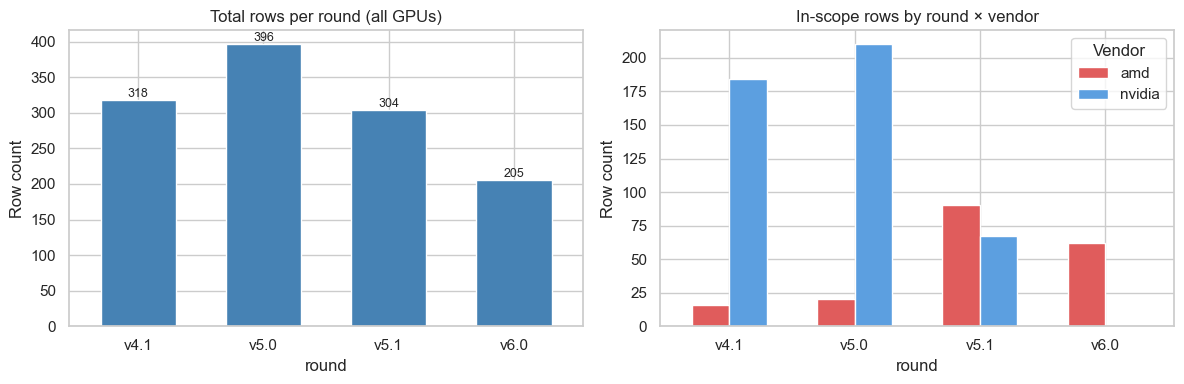

In [22]:
# ── Round-over-round growth ───────────────────────────────────────────────────
VENDOR_COLORS = {"amd": "#E05C5C", "nvidia": "#5C9FE0"}
round_order   = ["v4.1", "v5.0", "v5.1", "v6.0"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_e.groupby("round").size().reindex(round_order).plot(
    kind="bar", ax=axes[0], color="steelblue", width=0.6
)
axes[0].set_title("Total rows per round (all GPUs)")
axes[0].set_ylabel("Row count")
axes[0].tick_params(axis="x", rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

vendor_round = (
    in_scope.groupby(["round", "gpu_vendor"])
    .size()
    .unstack(fill_value=0)
    .reindex(round_order)
)
# Explicit color mapping — don't assume alphabetical unstack order
col_colors = [VENDOR_COLORS.get(v, "gray") for v in vendor_round.columns]
vendor_round.plot(kind="bar", ax=axes[1], color=col_colors, width=0.6)
axes[1].set_title("In-scope rows by round × vendor")
axes[1].set_ylabel("Row count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Vendor")

plt.tight_layout()
plt.show()

## §5 · Target Variable Analysis

In [23]:
tput = in_scope["throughput_tok_per_sec_per_gpu"].dropna()

skew_raw = sp_stats.skew(tput)
skew_log = sp_stats.skew(np.log10(tput))
range_ratio = tput.max() / tput.min()

print(f"n={len(tput):,}  min={tput.min():.0f}  median={tput.median():.0f}  max={tput.max():.0f}  range={range_ratio:.0f}×")
print(f"Skewness (raw):    {skew_raw:+.2f}")
print(f"Skewness (log₁₀):  {skew_log:+.2f}")
print()
if abs(skew_log) < abs(skew_raw):
    print(f"→ log₁₀ reduces skewness ({skew_raw:+.2f} → {skew_log:+.2f}).")
    print("  Use log₁₀(throughput_tok_per_sec_per_gpu) as the XGBoost target.")
else:
    print("→ Log transform does not improve skewness. Use raw target.")

n=649  min=11  median=4304  max=13441  range=1180×
Skewness (raw):    +1.85
Skewness (log₁₀):  -4.88

→ Log transform does not improve skewness. Use raw target.


/var/folders/6p/g0jwn7ns4rqc3q2g_c5z593w0000gn/T/ipykernel_82738/3388540659.py:39: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6p/g0jwn7ns4rqc3q2g_c5z593w0000gn/T/ipykernel_82738/3388540659.py:39: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/victoriaalabi/Projects/gpu-perf-prophet/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/victoriaalabi/Projects/gpu-perf-prophet/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


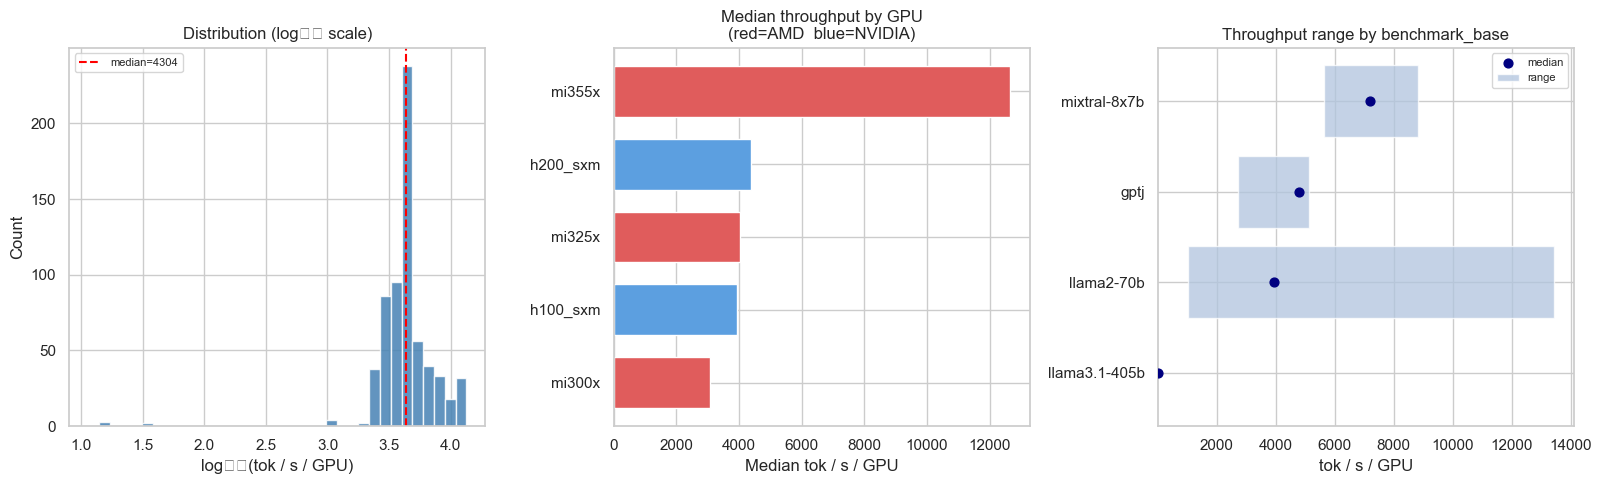

In [24]:
# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Log-scale histogram
axes[0].hist(np.log10(tput), bins=35, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(np.log10(tput.median()), color="red", ls="--", lw=1.5,
                label=f"median={tput.median():.0f}")
axes[0].set_title("Distribution (log₁₀ scale)")
axes[0].set_xlabel("log₁₀(tok / s / GPU)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

# 2. Median throughput by GPU (sorted bar, AMD=red / NVIDIA=blue)
gpu_med = (
    in_scope.groupby("canonical_gpu_id")["throughput_tok_per_sec_per_gpu"]
    .median()
    .sort_values(ascending=True)
)
bar_colors = ["#E05C5C" if gid.startswith("mi") else "#5C9FE0" for gid in gpu_med.index]
gpu_med.plot(kind="barh", ax=axes[1], color=bar_colors, width=0.7)
axes[1].set_title("Median throughput by GPU\n(red=AMD  blue=NVIDIA)")
axes[1].set_xlabel("Median tok / s / GPU")
axes[1].set_ylabel("")

# 3. Range by benchmark_base (min–max bar, median dot)
bench_stats = (
    in_scope.groupby("benchmark_base")["throughput_tok_per_sec_per_gpu"]
    .agg(["min", "median", "max"])
    .sort_values("median", ascending=True)
)
axes[2].barh(bench_stats.index, bench_stats["max"] - bench_stats["min"],
             left=bench_stats["min"], color="lightsteelblue", alpha=0.75, label="range")
axes[2].scatter(bench_stats["median"], bench_stats.index,
                color="navy", zorder=3, s=40, label="median")
axes[2].set_title("Throughput range by benchmark_base")
axes[2].set_xlabel("tok / s / GPU")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## §6 · Feature Candidate Sketches

/var/folders/6p/g0jwn7ns4rqc3q2g_c5z593w0000gn/T/ipykernel_82738/2973779316.py:35: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6p/g0jwn7ns4rqc3q2g_c5z593w0000gn/T/ipykernel_82738/2973779316.py:35: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


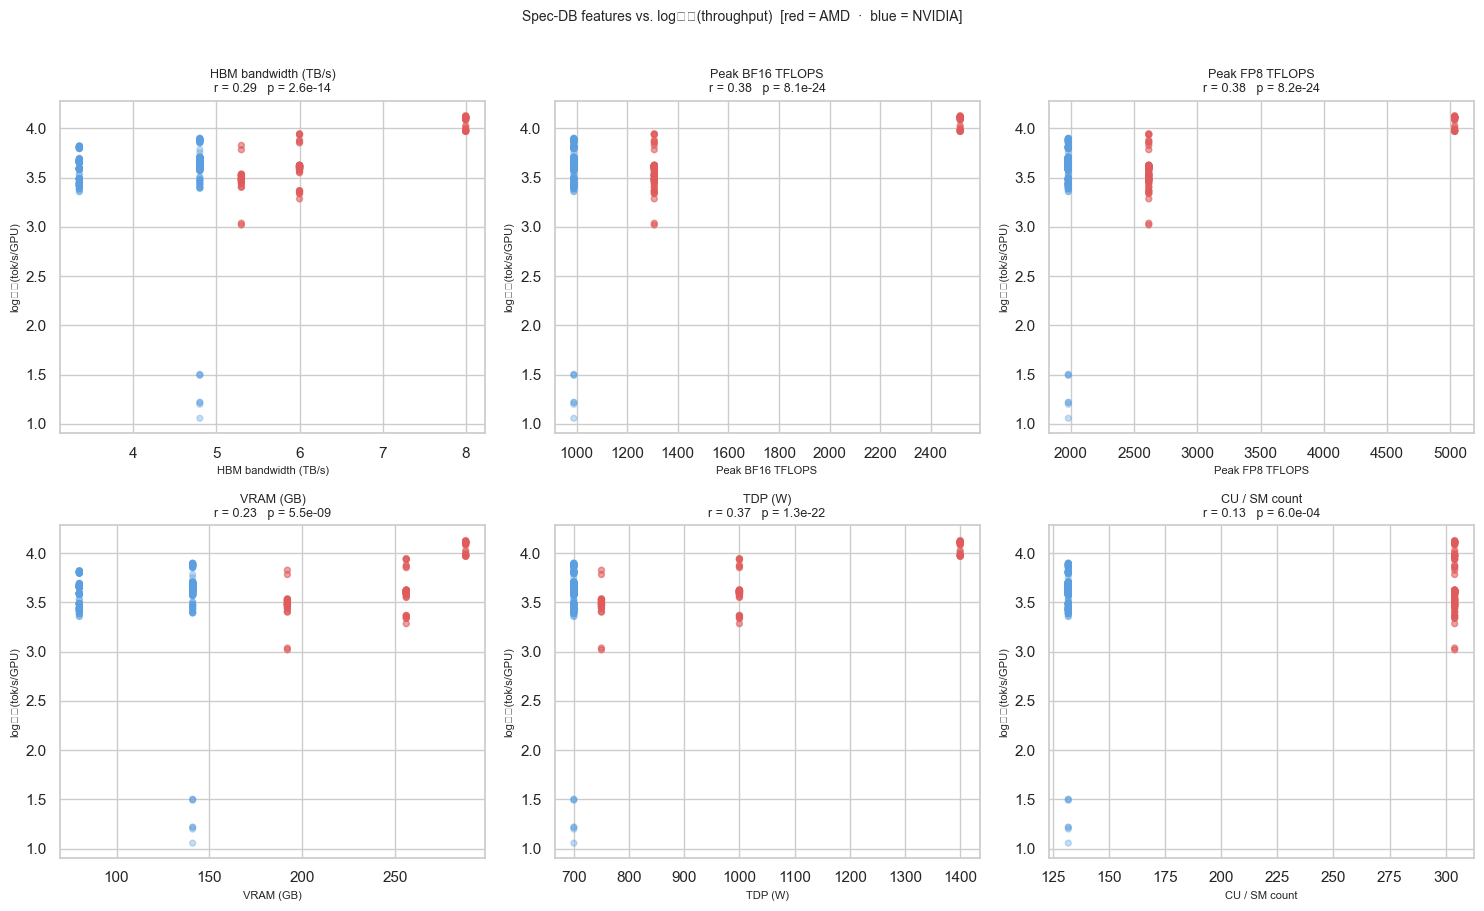

In [25]:
log_target = np.log10(in_scope["throughput_tok_per_sec_per_gpu"])

spec_feats = [
    ("gpu_hbm_bandwidth_tbps", "HBM bandwidth (TB/s)"),
    ("gpu_peak_bf16_tflops",   "Peak BF16 TFLOPS"),
    ("gpu_peak_fp8_tflops",    "Peak FP8 TFLOPS"),
    ("gpu_vram_gb",            "VRAM (GB)"),
    ("gpu_tdp_w",              "TDP (W)"),
    ("gpu_cu_sm_count",        "CU / SM count"),
]

# ── Spec-DB feature correlations ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

# Hoist loop-invariants: log_target.notna() and the vendor column are the
# same every iteration; recomputing them 6× is wasteful.
log_target_notna = log_target.notna()
vendor           = in_scope["gpu_vendor"]

for ax, (feat, label) in zip(axes, spec_feats):
    mask = in_scope[feat].notna() & log_target_notna
    x, y = in_scope.loc[mask, feat], log_target[mask]
    r, p = sp_stats.pearsonr(x, y)
    pt_colors = ["#E05C5C" if v == "amd" else "#5C9FE0" for v in vendor[mask]]
    ax.scatter(x, y, alpha=0.35, s=18, c=pt_colors)
    ax.set_title(f"{label}\nr = {r:.2f}   p = {p:.1e}", fontsize=9)
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel("log₁₀(tok/s/GPU)", fontsize=8)

plt.suptitle(
    "Spec-DB features vs. log₁₀(throughput)  [red = AMD  ·  blue = NVIDIA]",
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()

/var/folders/6p/g0jwn7ns4rqc3q2g_c5z593w0000gn/T/ipykernel_82738/3821462465.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/var/folders/6p/g0jwn7ns4rqc3q2g_c5z593w0000gn/T/ipykernel_82738/3821462465.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
/var/folders/6p/g0jwn7ns4rqc3q2g_c5z593w0000gn/T/ipykernel_82738/3821462465.py:22: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6p/g0jwn7ns4rqc3q2g_c5z593w0000gn/T/ipykernel_82738/3821462465.py:22: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/victoriaalabi/Projects/gpu-perf-prophet/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.

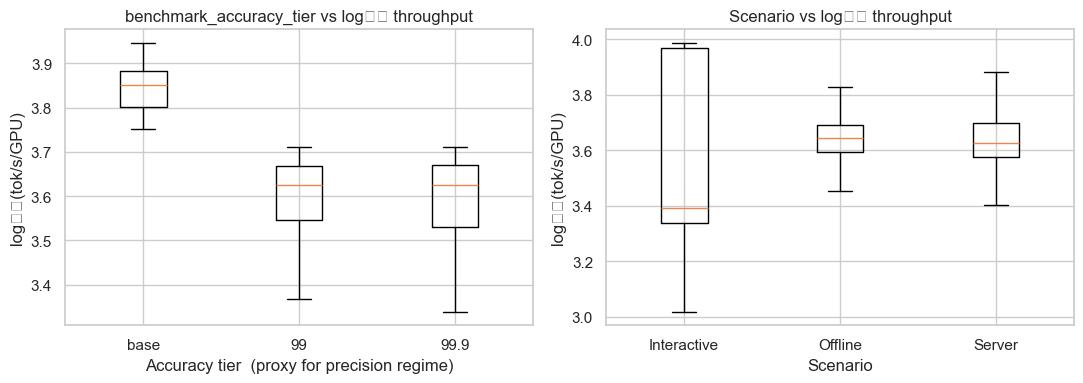

In [26]:
# ── Categorical features ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

tier_order = ["base", "99", "99.9"]
axes[0].boxplot(
    [log_target[in_scope["benchmark_accuracy_tier"] == t].dropna() for t in tier_order],
    labels=tier_order, showfliers=False,
)
axes[0].set_title("benchmark_accuracy_tier vs log₁₀ throughput")
axes[0].set_xlabel("Accuracy tier  (proxy for precision regime)")
axes[0].set_ylabel("log₁₀(tok/s/GPU)")

scenarios = sorted(in_scope["scenario"].unique())
axes[1].boxplot(
    [log_target[in_scope["scenario"] == s].dropna() for s in scenarios],
    labels=scenarios, showfliers=False,
)
axes[1].set_title("Scenario vs log₁₀ throughput")
axes[1].set_xlabel("Scenario")
axes[1].set_ylabel("log₁₀(tok/s/GPU)")

plt.tight_layout()
plt.show()

### Feature list

Based on §4–§6. Features marked **engineer** don't exist in the raw data and must be built in `src/features/`.

| Feature | Source | Evidence / rationale |
|---------|---------|----------------------|
| `gpu_hbm_bandwidth_tbps` | spec DB | Highest r with log throughput — memory bandwidth is the dominant roofline bottleneck for LLM inference |
| `gpu_peak_bf16_tflops` / `gpu_peak_fp8_tflops` | spec DB | Compute ceiling; which precision peak matters depends on `benchmark_accuracy_tier` |
| `gpu_vram_gb` | spec DB | Larger VRAM → larger KV-cache batch → higher Offline throughput |
| `gpu_cu_sm_count` | spec DB | Parallel execution units; second-order effect after bandwidth |
| `gpu_tdp_w` | spec DB | Power budget proxy; also used in Pareto recommender cost objective |
| `benchmark_accuracy_tier` | parser | 100% populated; encodes `base` / `99` / `99.9` precision regime — expect near top of SHAP |
| `benchmark_base` | parser | Model family identity — encodes architecture and parameter count indirectly |
| `tokens_per_sample` | parser | Output-length regime (verified); already the divisor in the target variable |
| `scenario` | parser | Offline vs Server changes optimization objective and request-batching dynamics |
| `model_params_B` | **engineer** | Derive from `benchmark_base`: gptj=6B, llama2-70b=70B, mixtral-8x7b=46.7B, llama3.1-405b=405B |
| `arithmetic_intensity` | **engineer** | FLOPs / bytes — key roofline input; build in `src/features/roofline.py` |

**Drop:** `vram_gb` (parser-reported, unreliable for multi-GPU), `precision` (0% populated), raw latency columns (leakage if used as features for a throughput target), `submitter` (high cardinality, leakage risk).